In [1]:
%pip install sentence_transformers
!pip install chromadb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.0/23.0 MB 118.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 63.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 135.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.1/72.1 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.6/231.6 kB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 7.7 MB/s eta 0:00:00
  Attempting uninstall: opentelemetry-proto
    Found existing installation: opentelemetry-proto 1.38.0
    Uninstalling opent

In [2]:
import pandas as pd
import requests
import gzip,shutil
import os


In [3]:
# URLs of IMDb datasets
dataset_urls = {
    'title.basics': 'https://datasets.imdbws.com/title.basics.tsv.gz',
    'title.crew': 'https://datasets.imdbws.com/title.crew.tsv.gz',
    'title.episode': 'https://datasets.imdbws.com/title.episode.tsv.gz',
    'title.ratings': 'https://datasets.imdbws.com/title.ratings.tsv.gz',
    'name.basics': 'https://datasets.imdbws.com/name.basics.tsv.gz'
}

def download_and_extract(url, output_path):
    response = requests.get(url, stream=True)
    with open(output_path, 'wb') as out_file:
        shutil.copyfileobj(response.raw, out_file)
    with gzip.open(output_path, 'rb') as f_in:
        with open(output_path.replace('.gz', ''), 'wb') as f_out:
            shutil.copyfileobj(f_in, f_out)
    os.remove(output_path)  # Remove the compressed file

for name, url in dataset_urls.items():
    download_and_extract(url, f'{name}.tsv.gz')

In [4]:
name_basics = pd.read_csv("name.basics.tsv", sep ="\t")


In [5]:
name_basics.head()

,nconst,primaryName,birthYear,deathYear,primaryProfession,knownForTitles
0,nm0000001,Fred Astaire,1899,1987,"actor,miscellaneous,producer","tt0072308,tt0050419,tt0027125,tt0025164"
1,nm0000002,Lauren Bacall,1924,2014,"actress,miscellaneous,soundtrack","tt0037382,tt0075213,tt0038355,tt0045891"
2,nm0000003,Brigitte Bardot,1934,2025,"actress,music_department,producer","tt0057345,tt0049189,tt0056404,tt0054452"
3,nm0000004,John Belushi,1949,1982,"actor,writer,music_department","tt0072562,tt0077975,tt0080455,tt0078723"
4,nm0000005,Ingmar Bergman,1918,2007,"writer,director,actor","tt0050986,tt0069467,tt0050976,tt0083922"


In [6]:
name_basics.drop(columns=["knownForTitles","primaryProfession","birthYear","deathYear"],inplace= True)

In [7]:
title_basics = pd.read_csv("title.basics.tsv", sep ="\t")

In [8]:
title_basics.head()

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres
0,tt0000001,short,Carmencita,Carmencita,0,1894,\N,1,"Documentary,Short"
1,tt0000002,short,Le clown et ses chiens,Le clown et ses chiens,0,1892,\N,5,"Animation,Short"
2,tt0000003,short,Poor Pierrot,Pauvre Pierrot,0,1892,\N,5,"Animation,Comedy,Romance"
3,tt0000004,short,Un bon bock,Un bon bock,0,1892,\N,12,"Animation,Short"
4,tt0000005,short,Blacksmith Scene,Blacksmith Scene,0,1893,\N,1,Short


In [9]:
title_basics.drop(columns=["primaryTitle","endYear","isAdult"],inplace=True)


In [10]:
title_crew = pd.read_csv("title.crew.tsv", sep = "\t")


In [11]:
title_crew.head()

,tconst,directors,writers
0,tt0000001,nm0005690,\N
1,tt0000002,nm0721526,\N
2,tt0000003,nm0721526,nm0721526
3,tt0000004,nm0721526,\N
4,tt0000005,nm0005690,\N


In [12]:
title_crew.drop(columns=["writers"],inplace=True)

In [13]:
title_ratings = pd.read_csv("title.ratings.tsv", sep ="\t")


In [14]:
title_ratings.head()

,tconst,averageRating,numVotes
0,tt0000001,5.7,2201
1,tt0000002,5.5,312
2,tt0000003,6.4,2314
3,tt0000004,5.1,197
4,tt0000005,6.2,3039


In [15]:
title_episode = pd.read_csv("title.episode.tsv",usecols=["tconst"],sep="\t")

In [16]:
exclude_idx=title_episode["tconst"].values

In [17]:
# Merge the datasets
merged_df = title_basics.merge(title_crew, on='tconst', how='left') \
                      .merge(title_ratings, on='tconst', how='left')


In [18]:
merged_df.rename(columns={'directors':'nconst'},inplace=True)

In [19]:
merged_df = merged_df[~merged_df['tconst'].isin(exclude_idx)]


In [20]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2831656 entries, 0 to 12420964
Data columns (total 9 columns):
 #   Column          Dtype  
---  ------          -----  
 0   tconst          object 
 1   titleType       object 
 2   originalTitle   object 
 3   startYear       object 
 4   runtimeMinutes  object 
 5   genres          object 
 6   nconst          object 
 7   averageRating   float64
 8   numVotes        float64
dtypes: float64(2), object(7)
memory usage: 216.0+ MB


In [21]:
merged_df = merged_df.merge(name_basics,on="nconst",how="left")

In [22]:
merged_df.drop(columns=["nconst"],inplace=True)


In [23]:
merged_df.titleType.unique()

array(['short', 'movie', 'tvShort', 'tvSeries', 'tvMovie', 'tvMiniSeries',
       'tvSpecial', 'video', 'videoGame', 'tvEpisode', 'tvPilot'],
      dtype=object)

In [24]:
merged_df = merged_df.query('titleType=="movie" or titleType =="tvSeries" or titleType == "tvMovie"')

### Del df to save memory

In [25]:
del name_basics
del title_basics
del title_crew
del title_episode
del title_ratings

## MovieLens Data

In [26]:
import requests
import zipfile
import os

def download_and_extract_zip(url, output_path):
    # Step 1: Download the ZIP file
    try:
        print(f"Downloading from {url}...")
        response = requests.get(url)
        response.raise_for_status()  # Will raise an exception for bad responses
        zip_path = 'temp.zip'  # Temporary path for the downloaded file

        with open(zip_path, 'wb') as f:
            f.write(response.content)

        print(f"Downloaded ZIP to {zip_path}.")

    except requests.exceptions.RequestException as e:
        print(f"Error downloading the file: {e}")
        return

    # Step 2: Extract the ZIP file
    try:
        print(f"Extracting {zip_path} to {output_path}...")

        # Create the output_path  if it doesn't exist
        if not os.path.exists(output_path):
            os.makedirs(output_path)

        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(output_path)

    except zipfile.BadZipFile:
        print(f"Error: {zip_path} is not a valid ZIP file.")
    except Exception as e:
        print(f"Error extracting the ZIP file: {e}")

    # Clean up the temporary zip file
    os.remove(zip_path)
    print("Temporary ZIP file removed.")

# Example usage:
url = "https://files.grouplens.org/datasets/movielens/ml-32m.zip"  # Replace with your actual URL
output_path = "./"  # Folder where you want to extract the contents

download_and_extract_zip(url, output_path)


Downloaded ZIP to temp.zip.
Extracting temp.zip to ./...
Temporary ZIP file removed.


In [27]:
rates = pd.read_csv("ml-32m/ratings.csv")

In [28]:
rates.isna().sum()

,0
userId,0
movieId,0
rating,0
timestamp,0


In [29]:
rates

,userId,movieId,rating,timestamp
0,1,17,4.0,944249077
1,1,25,1.0,944250228
2,1,29,2.0,943230976
3,1,30,5.0,944249077
4,1,32,5.0,943228858
...,...,...,...,...
32000199,200948,79702,4.5,1294412589
32000200,200948,79796,1.0,1287216292
32000201,200948,80350,0.5,1294412671
32000202,200948,80463,3.5,1350423800


In [30]:
rates=rates.groupby("movieId")["rating"].mean().to_frame()

In [31]:
tags = pd.read_csv("ml-32m/tags.csv")

In [32]:
tags["tag"] = tags["tag"].astype("str")

In [33]:
tags = tags.groupby('movieId')['tag'].apply(lambda x: ', '.join(x.value_counts().head(10).index)).to_frame()

In [34]:
mv_data = rates.merge(tags , left_index = True, right_index = True, how ="left")

In [35]:
mv_data.head()

,rating,tag
movieId,,
1,3.897438,"Pixar, animation, Disney, funny, Tom Hanks, pi..."
2,3.275758,"Robin Williams, fantasy, time travel, board ga..."
3,3.139447,"comedinha de velhinhos engraÃƒÂ§ada, comedinha..."
4,2.845331,"chick flick, characters, slurs, based on novel..."
5,3.059602,"pregnancy, Steve Martin, family, daughter, Dia..."


In [36]:
links = pd.read_csv("ml-32m/links.csv", usecols=["movieId", "imdbId"], dtype={"imdbId": str})


In [37]:
mv_data = mv_data.merge(links, left_index=True, right_on="movieId", how = "left")

In [38]:
mv_data.drop(columns=["movieId"],inplace=True)

In [39]:
mv_data["imdbId"] = "tt" + mv_data["imdbId"].astype(str)

In [40]:
mv_data.rename(columns={"rating":"movielens_rating","imdbId":"tconst"},inplace = True)

In [41]:
merged_df = merged_df.merge(mv_data,on="tconst",how="left")

In [42]:
merged_df.titleType.unique()

array(['movie', 'tvSeries', 'tvMovie'], dtype=object)

## EXTERNAL KAGGLE DATA

In [43]:
!pip install kagglehub

In [44]:
!export KAGGLEHUB_CACHE=


In [45]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("alanvourch/tmdb-movies-daily-updates")

print("Path to dataset files:", path)

100%|██████████| 297M/297M [00:01<00:00, 178MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/alanvourch/tmdb-movies-daily-updates/versions/833


In [46]:
filename = "TMDB_all_movies.csv"
file_path = os.path.join(path,filename)

In [47]:
kaggle_df = pd.read_csv(file_path, usecols=["imdb_id", "overview", "imdb_rating", "imdb_votes"])
kaggle_df = kaggle_df[kaggle_df['imdb_id'].notna()]

In [48]:
cn = ["tconst", "overview", "averageRating", "numVotes" ]
kaggle_df.columns = cn

In [49]:
kaggle_df.head()

,tconst,overview,averageRating,numVotes
0,tt0094675,A Finnish man goes to the city to find a job a...,7.4,9716.0
1,tt0092149,"Nikander, a rubbish collector and would-be ent...",7.4,8593.0
2,tt0113101,It's Ted the Bellhop's first night on the job....,6.7,116748.0
3,tt0107286,"Four young friends, while taking a shortcut en...",6.6,20999.0
4,tt0825671,Timo Novotny labels his new project an experim...,8.1,285.0


In [50]:
merged_df.drop(columns = ["averageRating","numVotes"],inplace=True)

In [51]:
merged_df.head()

,tconst,titleType,originalTitle,startYear,runtimeMinutes,genres,primaryName,movielens_rating,tag
0,tt0000009,movie,Miss Jerry,1894,45,Romance,Alexander Black,NaN,NaN
1,tt0000147,movie,The Corbett-Fitzsimmons Fight,1897,100,"Documentary,News,Sport",Enoch J. Rector,NaN,NaN
2,tt0000502,movie,Bohemios,1905,100,\N,Ricardo de Baños,NaN,NaN
3,tt0000574,movie,The Story of the Kelly Gang,1906,70,"Action,Adventure,Biography",Charles Tait,2.5,"partially lost film, silent film"
4,tt0000591,movie,L'enfant prodigue,1907,90,Drama,Michel Carré,NaN,NaN


In [52]:
merged_df = merged_df.merge(kaggle_df, on="tconst", how="left")

### Data Visualization

In [53]:
import seaborn as sns

<Axes: xlabel='averageRating', ylabel='numVotes'>

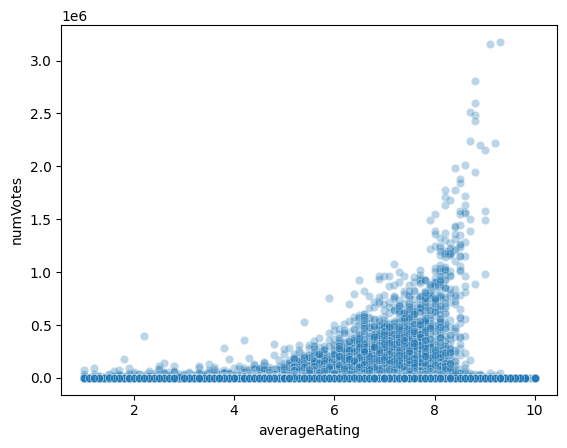

In [54]:
sns.scatterplot(merged_df,x="averageRating",y="numVotes",alpha = 0.3)

In [55]:
import chromadb.utils.embedding_functions as embedding_functions


In [56]:
merged_df.rename(columns={'primaryName':'director'},inplace=True)

In [57]:
merged_df.head()

,tconst,titleType,originalTitle,startYear,runtimeMinutes,genres,director,movielens_rating,tag,overview,averageRating,numVotes
0,tt0000009,movie,Miss Jerry,1894,45,Romance,Alexander Black,NaN,NaN,The adventures of a female reporter in the 1890s.,5.3,236.0
1,tt0000147,movie,The Corbett-Fitzsimmons Fight,1897,100,"Documentary,News,Sport",Enoch J. Rector,NaN,NaN,"This legendary fight was filmed on March 17, 1...",5.3,600.0
2,tt0000502,movie,Bohemios,1905,100,\N,Ricardo de Baños,NaN,NaN,NaN,NaN,NaN
3,tt0000574,movie,The Story of the Kelly Gang,1906,70,"Action,Adventure,Biography",Charles Tait,2.5,"partially lost film, silent film",Just as Galeen and Wegener's Der Golem (1915) ...,6.0,1067.0
4,tt0000591,movie,L'enfant prodigue,1907,90,Drama,Michel Carré,NaN,NaN,The first feature-length motion picture produc...,5.0,39.0


In [58]:
merged_df.dropna(subset=['tag', 'overview'],how ="all",inplace=True)


In [59]:
merged_df.head()

,tconst,titleType,originalTitle,startYear,runtimeMinutes,genres,director,movielens_rating,tag,overview,averageRating,numVotes
0,tt0000009,movie,Miss Jerry,1894,45,Romance,Alexander Black,NaN,NaN,The adventures of a female reporter in the 1890s.,5.3,236.0
1,tt0000147,movie,The Corbett-Fitzsimmons Fight,1897,100,"Documentary,News,Sport",Enoch J. Rector,NaN,NaN,"This legendary fight was filmed on March 17, 1...",5.3,600.0
3,tt0000574,movie,The Story of the Kelly Gang,1906,70,"Action,Adventure,Biography",Charles Tait,2.5,"partially lost film, silent film",Just as Galeen and Wegener's Der Golem (1915) ...,6.0,1067.0
4,tt0000591,movie,L'enfant prodigue,1907,90,Drama,Michel Carré,NaN,NaN,The first feature-length motion picture produc...,5.0,39.0
5,tt0000615,movie,Robbery Under Arms,1907,\N,Drama,Charles MacMahon,NaN,NaN,Australian bushranger movie. The first filmed...,3.4,34.0


In [60]:
merged_df.isnull().sum()

,0
tconst,0
titleType,0
originalTitle,1
startYear,0
runtimeMinutes,0
genres,0
director,42389
movielens_rating,312219
tag,342678
overview,131


In [61]:
CUDA_LAUNCH_BLOCKING=1

In [70]:

import pandas as pd
from tqdm import tqdm
import chromadb
import torch
from sentence_transformers import SentenceTransformer

# GPU Kontrolü
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Kullanılan cihaz: {device} (Hızlı işlem için 'cuda' olmalı!)")

model = SentenceTransformer("intfloat/multilingual-e5-base", device=device, trust_remote_code=True)

chroma_client = chromadb.PersistentClient(path="./long_term_memory")
collection = chroma_client.get_or_create_collection(name="imdb_data")

def create_vector_document(row):
    """Create structured content for vector database"""
    content_parts = []
    content_parts.append(f"Title: {row['originalTitle']}")
    content_parts.append(f"Title Type: {row['titleType']}")
    content_parts.append(f"Genres: {row['genres']}")
    content_parts.append(f"Year: {row['startYear']}")
    content_parts.append(f"Runtime: {row['runtimeMinutes']} minutes")

    if pd.notna(row['director']): content_parts.append(f"Director: {row['director']}")
    if pd.notna(row['overview']): content_parts.append(f"Overview: {row['overview']}")
    if pd.notna(row['averageRating']): content_parts.append(f"Imdb Rating: {row['averageRating']}")
    if pd.notna(row['numVotes']): content_parts.append(f"Number of Votes: {row['numVotes']}")
    if pd.notna(row['movielens_rating']): content_parts.append(f"MovieLens Rating: {row['movielens_rating']}")
    if pd.notna(row['tag']): content_parts.append(f"Tag: {row['tag']}")

    metadata = {
        "originalTitle": str(row['originalTitle']),
        "genre": str(row['genres']),
        "titleType": str(row['titleType'])
    }
    return {
        "id": str(row['tconst']),
        "document": " | ".join(content_parts)[:1000],
        "metadata": metadata
    }

BATCH_SIZE = 5000
print(f"Toplam {len(merged_df)} belge işlenecek.")

for i in tqdm(range(0, len(merged_df), BATCH_SIZE), desc="Batch İşleniyor"):
    batch_df = merged_df.iloc[i : i + BATCH_SIZE]

    # iterrows yerine to_dict('records') kullanmak çok daha hızlıdır
    records = batch_df.to_dict('records')

    batch_documents = []
    batch_metadatas = []
    batch_ids = []

    for row in records:
        doc = create_vector_document(row)
        batch_documents.append(doc["document"])
        batch_metadatas.append(doc["metadata"])
        batch_ids.append(doc["id"])

    try:
        # GPU'yu en verimli şekilde kullanmak için modeli doğrudan çağırıyoruz
        # encode içindeki batch_size, GPU VRAM'ine göre artırılabilir (örn: 256 veya 512)
        embeddings = model.encode(batch_documents, batch_size=256, show_progress_bar=False, convert_to_numpy=True).tolist()

        collection.add(
            documents=batch_documents,
            embeddings=embeddings,
            metadatas=batch_metadatas,
            ids=batch_ids
        )
    except Exception as e:
        print(f"\nBatch eklenirken hata oluştu (indeks: {i}): {e}")

print("\nTüm belgeler ChromaDB'ye başarıyla eklendi.")


Kullanılan cihaz: cuda (Hızlı işlem için 'cuda' olmalı!)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-base
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Toplam 386618 belge işlenecek.


Batch İşleniyor: 100%|██████████| 78/78 [20:55<00:00, 16.09s/it]


Tüm belgeler ChromaDB'ye başarıyla eklendi.


In [73]:
!pip install boto3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 136.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 12.3 MB/s eta 0:00:00


In [80]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [81]:
import shutil

# Source folder in Colab (e.g., your ChromaDB vector database)
source_folder = './long_term_memory'

# Destination folder in Google Drive
destination_folder = '/content/drive/MyDrive/long_term_memory_backup'

print(f"Copying {source_folder} to {destination_folder}...")

# Copy the folder contents to Google Drive
shutil.copytree(source_folder, destination_folder, dirs_exist_ok=True)

print("Folder successfully uploaded to Google Drive!")

Copying ./long_term_memory to /content/drive/MyDrive/long_term_memory_backup...
Folder successfully uploaded to Google Drive!
